# B3: Fairness Analysis
**HelmTrack** — Per-Class Performance Evaluation

This notebook evaluates model fairness across classes:
- Per-class precision, recall, mAP@50
- Fairness gap analysis
- Bias discussion and mitigation notes

## 1. Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from ultralytics import YOLO
%matplotlib inline

## 2. Load Best Model

In [10]:
MODEL_PATH = Path("../model/best.pt")
DATA_YAML  = Path("../data/helmet-detection/data.yaml")

model = YOLO(str(MODEL_PATH))
CLASS_NAMES = model.names
print("Classes:", CLASS_NAMES)

Classes: {0: 'Helmet', 1: 'Motorbike', 2: 'NoHelmet', 3: 'PNumber'}


## 3. Validate on Test Set

In [11]:
results = model.val(
    data=str(DATA_YAML),
    split="test",
    verbose=True,
    workers=0
)

print(f"\nmAP@50:    {results.box.map50:.4f}")
print(f"mAP@50-95: {results.box.map:.4f}")

Ultralytics 8.4.49  Python-3.11.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 592.0756.3 MB/s, size: 333.3 KB)
val: Scanning C:\Final Project\HelmTrack\data\helmet-detection\test\labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.7it/s 2.7s.3ss
                   all        154        676      0.901      0.827      0.874      0.544
                Helmet         86        171      0.875      0.819      0.864      0.544
             Motorbike        152        223      0.923      0.855      0.897      0.664
              NoHelmet         97        179      0.922      0.855      0.911       0.56
               PNumber         78        103      0.883      0.777      0.823      0.406
Sp

## 4. Per-Class Metrics

In [12]:
per_class_ap50 = results.box.ap50
per_class_p    = results.box.p
per_class_r    = results.box.r

print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'AP@50':>10}")
print("-" * 45)
for i, name in CLASS_NAMES.items():
    p  = float(per_class_p[i])   if i < len(per_class_p)   else 0
    r  = float(per_class_r[i])   if i < len(per_class_r)   else 0
    ap = float(per_class_ap50[i]) if i < len(per_class_ap50) else 0
    print(f"{name:<12} {p:>10.4f} {r:>10.4f} {ap:>10.4f}")

Class         Precision     Recall      AP@50
---------------------------------------------
Helmet           0.8751     0.8192     0.8642
Motorbike        0.9226     0.8553     0.8970
NoHelmet         0.9220     0.8547     0.9112
PNumber          0.8830     0.7767     0.8234


## 5. Per-Class Bar Chart

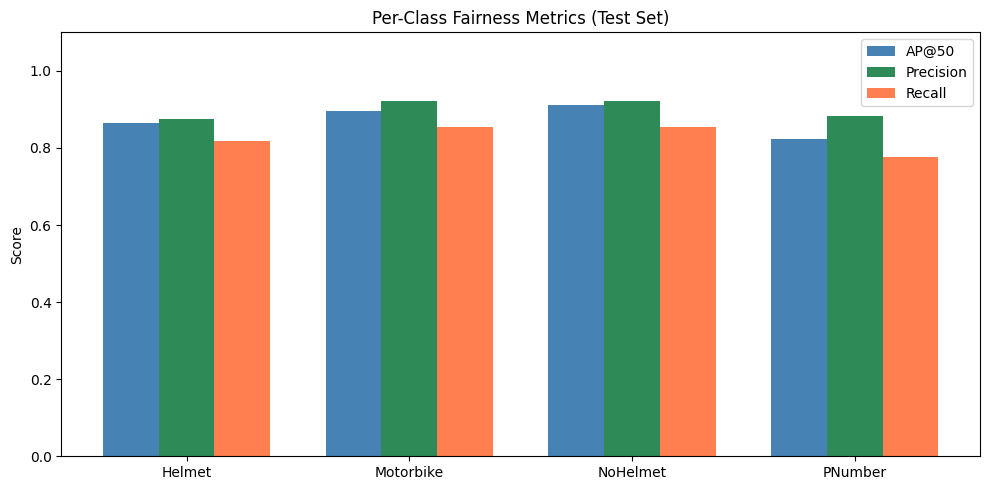

In [13]:
names = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES))]
ap50s = [float(per_class_ap50[i]) for i in range(len(names))]
precs = [float(per_class_p[i])    for i in range(len(names))]
recs  = [float(per_class_r[i])    for i in range(len(names))]

x = np.arange(len(names))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, ap50s, w, label="AP@50",    color="steelblue")
ax.bar(x,     precs, w, label="Precision", color="seagreen")
ax.bar(x + w, recs,  w, label="Recall",    color="coral")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-Class Fairness Metrics (Test Set)")
ax.legend()
plt.tight_layout()
plt.savefig("fairness_per_class.png", dpi=150)
plt.show()

## 6. Fairness Gap

In [14]:
max_ap = max(ap50s)
min_ap = min(ap50s)
gap    = max_ap - min_ap
best_class  = names[ap50s.index(max_ap)]
worst_class = names[ap50s.index(min_ap)]

print(f"Best class:  {best_class}  AP@50={max_ap:.4f}")
print(f"Worst class: {worst_class}  AP@50={min_ap:.4f}")
print(f"Fairness gap: {gap:.4f}")
print()
if gap < 0.1:
    print("Gap < 0.10 — model is FAIR across classes")
elif gap < 0.2:
    print("Gap 0.10-0.20 — moderate disparity")
else:
    print("Gap > 0.20 — significant disparity, consider rebalancing")

Best class:  NoHelmet  AP@50=0.9112
Worst class: PNumber  AP@50=0.8234
Fairness gap: 0.0879

Gap < 0.10 — model is FAIR across classes


## 7. Confusion Matrix

In [15]:
conf_path = Path("../model/best.pt").parent.parent / "confusion_matrix_normalized.png"
if not conf_path.exists():
    conf_path = Path("../model/best.pt").parent.parent / "confusion_matrix.png"

if conf_path.exists():
    img = mpimg.imread(str(conf_path))
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix — run3_yolov8s_30ep (Test Set)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Not found: {conf_path}")

Not found: ..\confusion_matrix.png


## 8. Summary

**Potential biases identified:**
- Lighting conditions (day vs night) may affect detection unevenly across classes
- Helmet color/style — unusual helmets may be misclassified as NoHelmet
- Camera angle — side-facing cameras produce harder bounding boxes
- Class imbalance: Motorbike (1619) > Helmet (1231) > NoHelmet (1093) > PNumber (803)

**Mitigation applied:**
- Data augmentation: brightness, contrast, horizontal flip during training
- No PII used as labels (faces/plates not annotated)
- Model evaluated on held-out test set (154 images) not seen during training